<a href="https://colab.research.google.com/github/gagelopezwhite/MATH-398/blob/main/398_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
wr.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("/content/Students Social Media Addiction.csv")
df = df.drop(0)
print(df.head())

   Student_ID  Age  Gender Academic_Level    Country  Avg_Daily_Usage_Hours  \
1           2   22    Male       Graduate      India                    2.1   
2           3   20  Female  Undergraduate        USA                    6.0   
3           4   18    Male    High School         UK                    3.0   
4           5   21    Male       Graduate     Canada                    4.5   
5           6   19  Female  Undergraduate  Australia                    7.2   

  Most_Used_Platform Affects_Academic_Performance  Sleep_Hours_Per_Night  \
1            Twitter                           No                    7.5   
2             TikTok                          Yes                    5.0   
3            YouTube                           No                    7.0   
4           Facebook                          Yes                    6.0   
5          Instagram                          Yes                    4.5   

   Mental_Health_Score Relationship_Status  Conflicts_Over_Social_Me

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.shape

(704, 13)

In [ ]:
df = df.drop('Student_ID', axis=1)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 1 to 704
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Age                           704 non-null    int64  
 1   Gender                        704 non-null    object 
 2   Academic_Level                704 non-null    object 
 3   Country                       704 non-null    object 
 4   Avg_Daily_Usage_Hours         704 non-null    float64
 5   Most_Used_Platform            704 non-null    object 
 6   Affects_Academic_Performance  704 non-null    object 
 7   Sleep_Hours_Per_Night         704 non-null    float64
 8   Mental_Health_Score           704 non-null    int64  
 9   Relationship_Status           704 non-null    object 
 10  Conflicts_Over_Social_Media   704 non-null    int64  
 11  Addicted_Score                704 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 66.1+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,704.0,20.661932,1.398811,18.0,19.75,21.0,22.0,24.0
Avg_Daily_Usage_Hours,704.0,4.918324,1.258244,1.5,4.10,4.8,5.8,8.5
Sleep_Hours_Per_Night,704.0,6.869460,1.127563,3.8,6.00,6.9,7.7,9.6
Mental_Health_Score,704.0,6.227273,1.105808,4.0,5.00,6.0,7.0,9.0
Conflicts_Over_Social_Media,704.0,2.849432,0.958632,0.0,2.00,3.0,4.0,5.0
Addicted_Score,704.0,6.434659,1.587197,2.0,5.00,7.0,8.0,9.0


In [ ]:
df.columns.tolist()

['Age',
 'Gender',
 'Academic_Level',
 'Country',
 'Avg_Daily_Usage_Hours',
 'Most_Used_Platform',
 'Affects_Academic_Performance',
 'Sleep_Hours_Per_Night',
 'Mental_Health_Score',
 'Relationship_Status',
 'Conflicts_Over_Social_Media',
 'Addicted_Score']

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,0
Relationship_Status,0


In [ ]:
df.nunique()

,0
Age,7
Gender,2
Academic_Level,3
Country,110
Avg_Daily_Usage_Hours,67
Most_Used_Platform,12
Affects_Academic_Performance,2
Sleep_Hours_Per_Night,59
Mental_Health_Score,6
Relationship_Status,3


In [ ]:
df['Academic_Level'].unique()


array(['Graduate', 'Undergraduate', 'High School'], dtype=object)

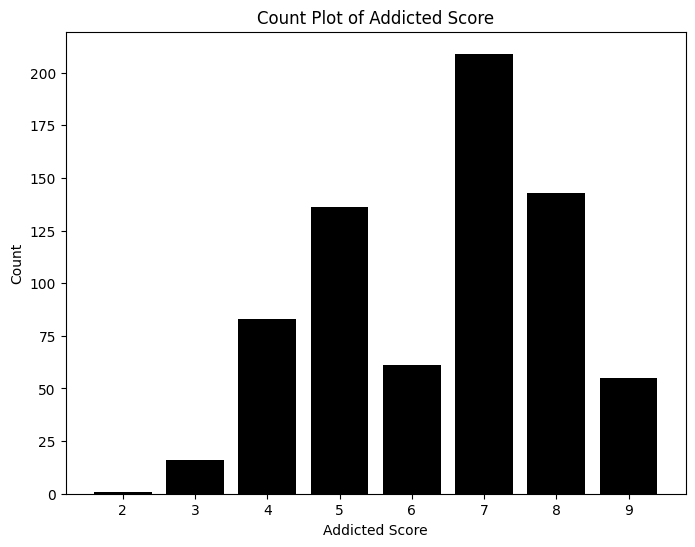

In [ ]:
quality_counts = df['Addicted_Score'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
plt.bar(quality_counts.index, quality_counts, color='black')
plt.title('Count Plot of Addicted Score')
plt.xlabel('Addicted Score')
plt.ylabel('Count')
plt.show()

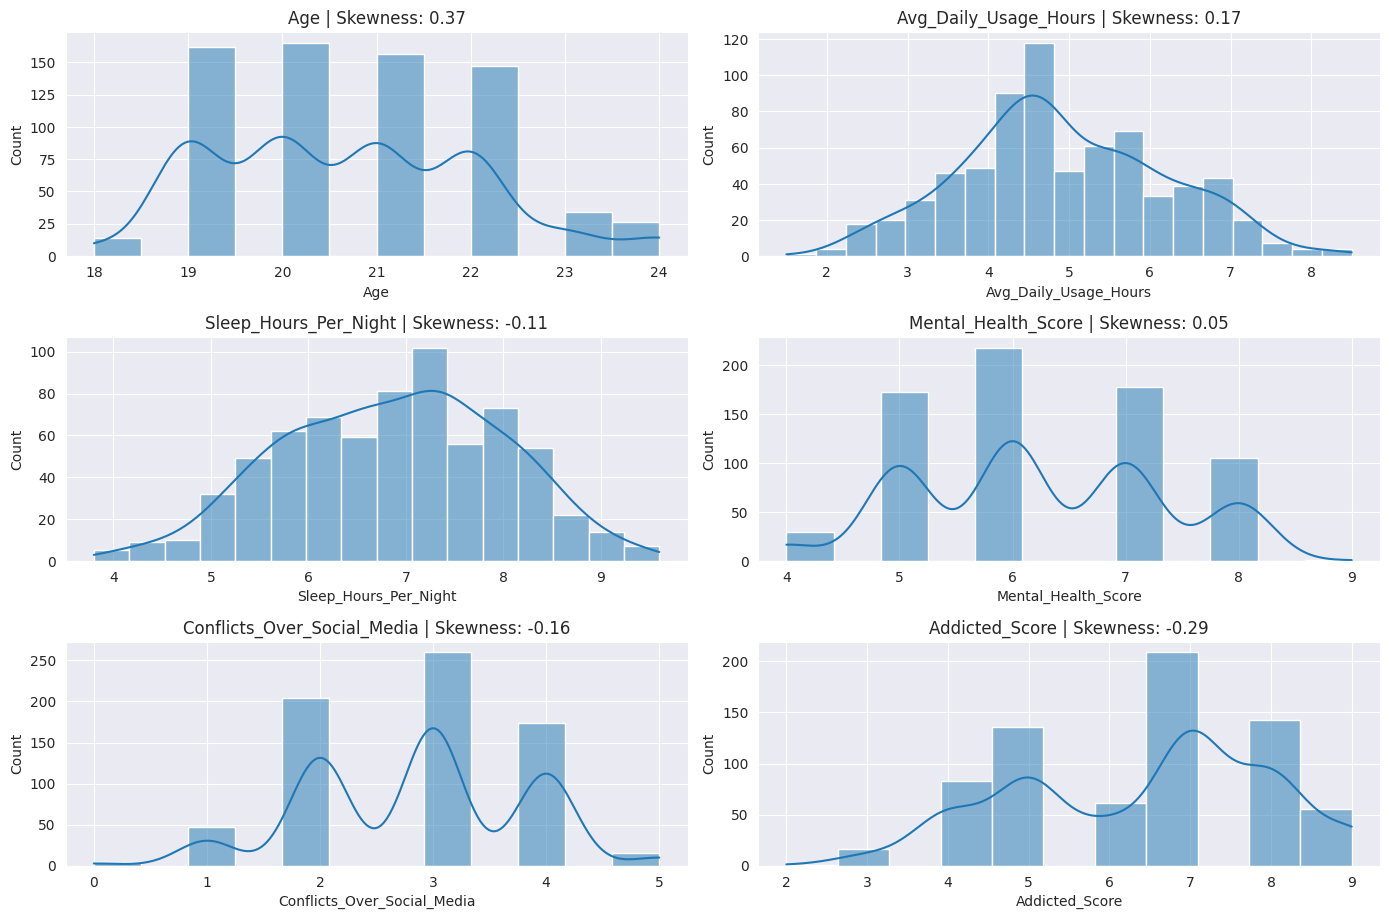

In [ ]:
sns.set_style("darkgrid")

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(14, len(numerical_columns) * 3))
for idx, feature in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

In [ ]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate entries: {duplicate_rows}")

Number of duplicate entries: 1


<Figure size 1000x600 with 0 Axes>

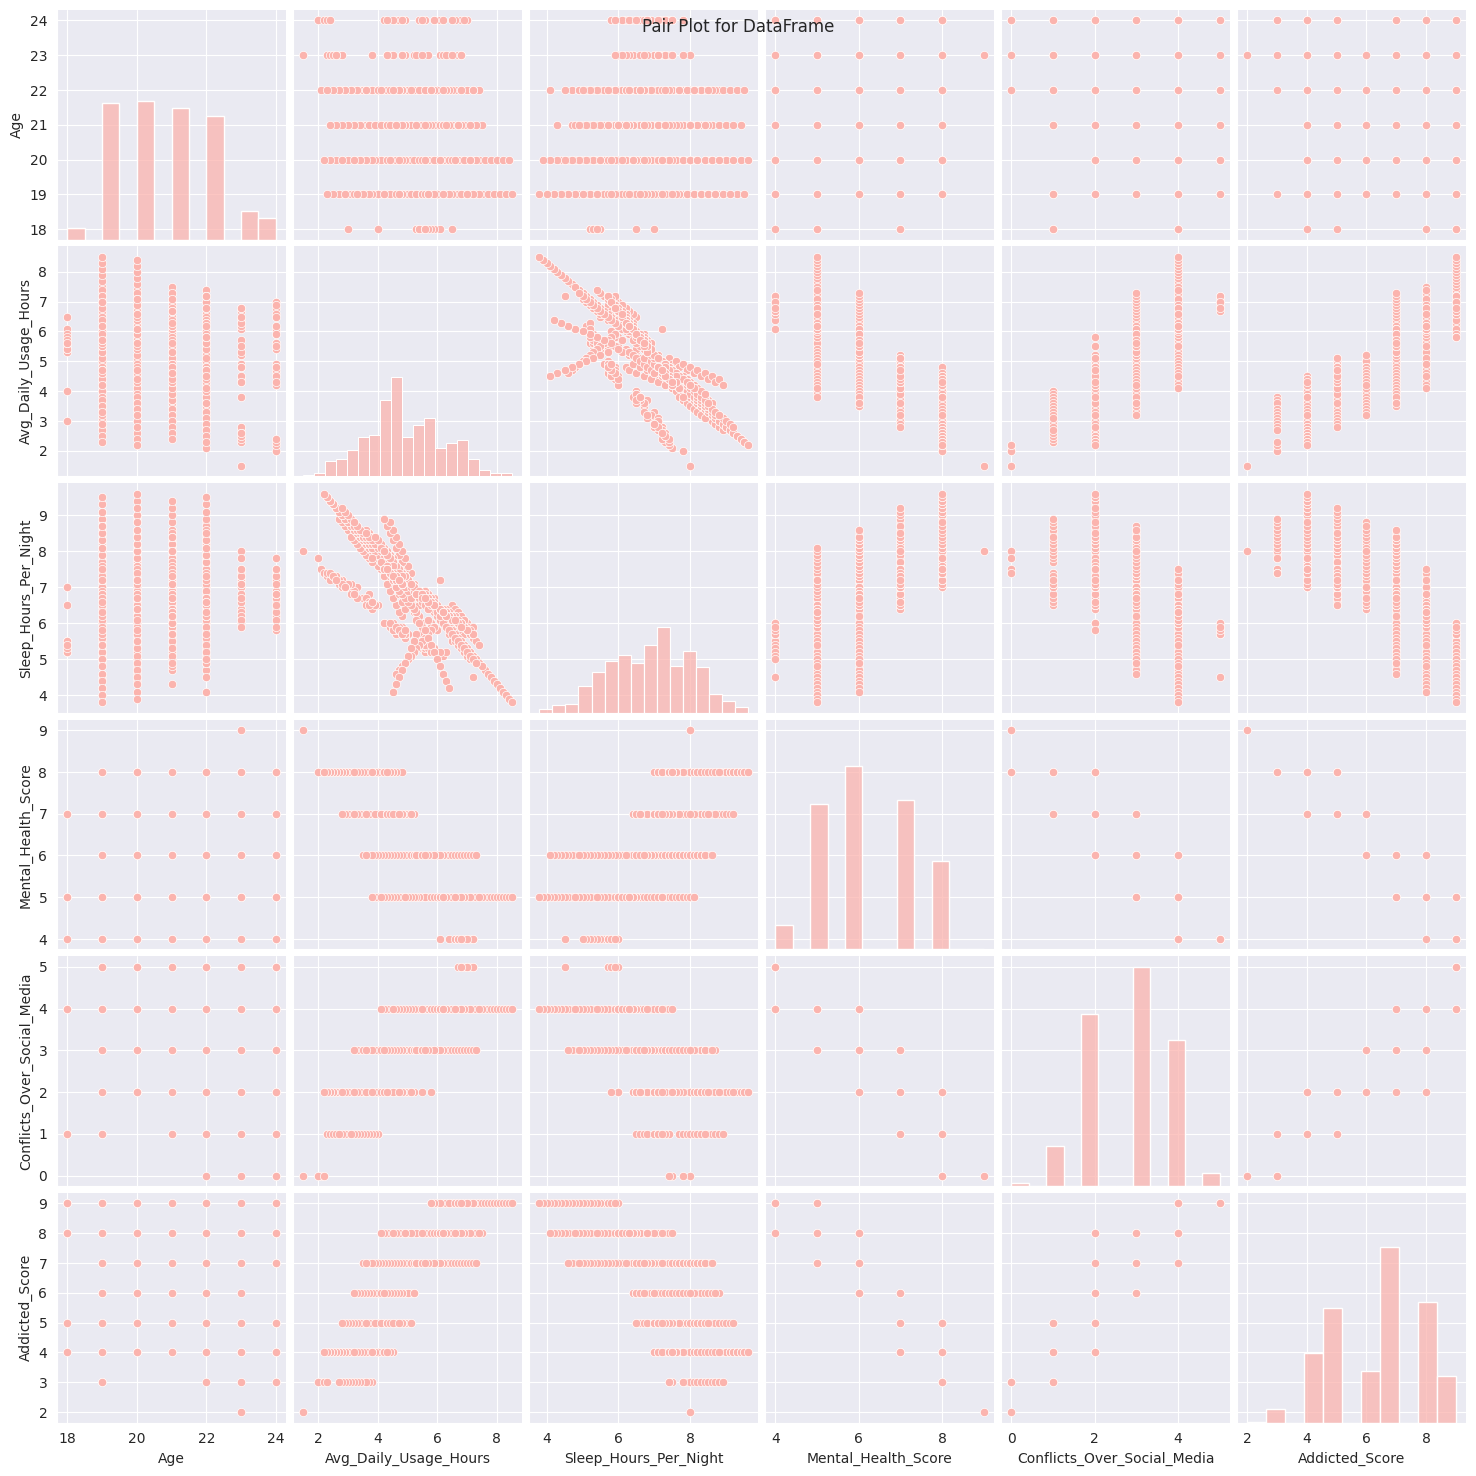

In [ ]:
sns.set_palette("Pastel1")

plt.figure(figsize=(10, 6))

sns.pairplot(df)

plt.suptitle('Pair Plot for DataFrame')
plt.show()

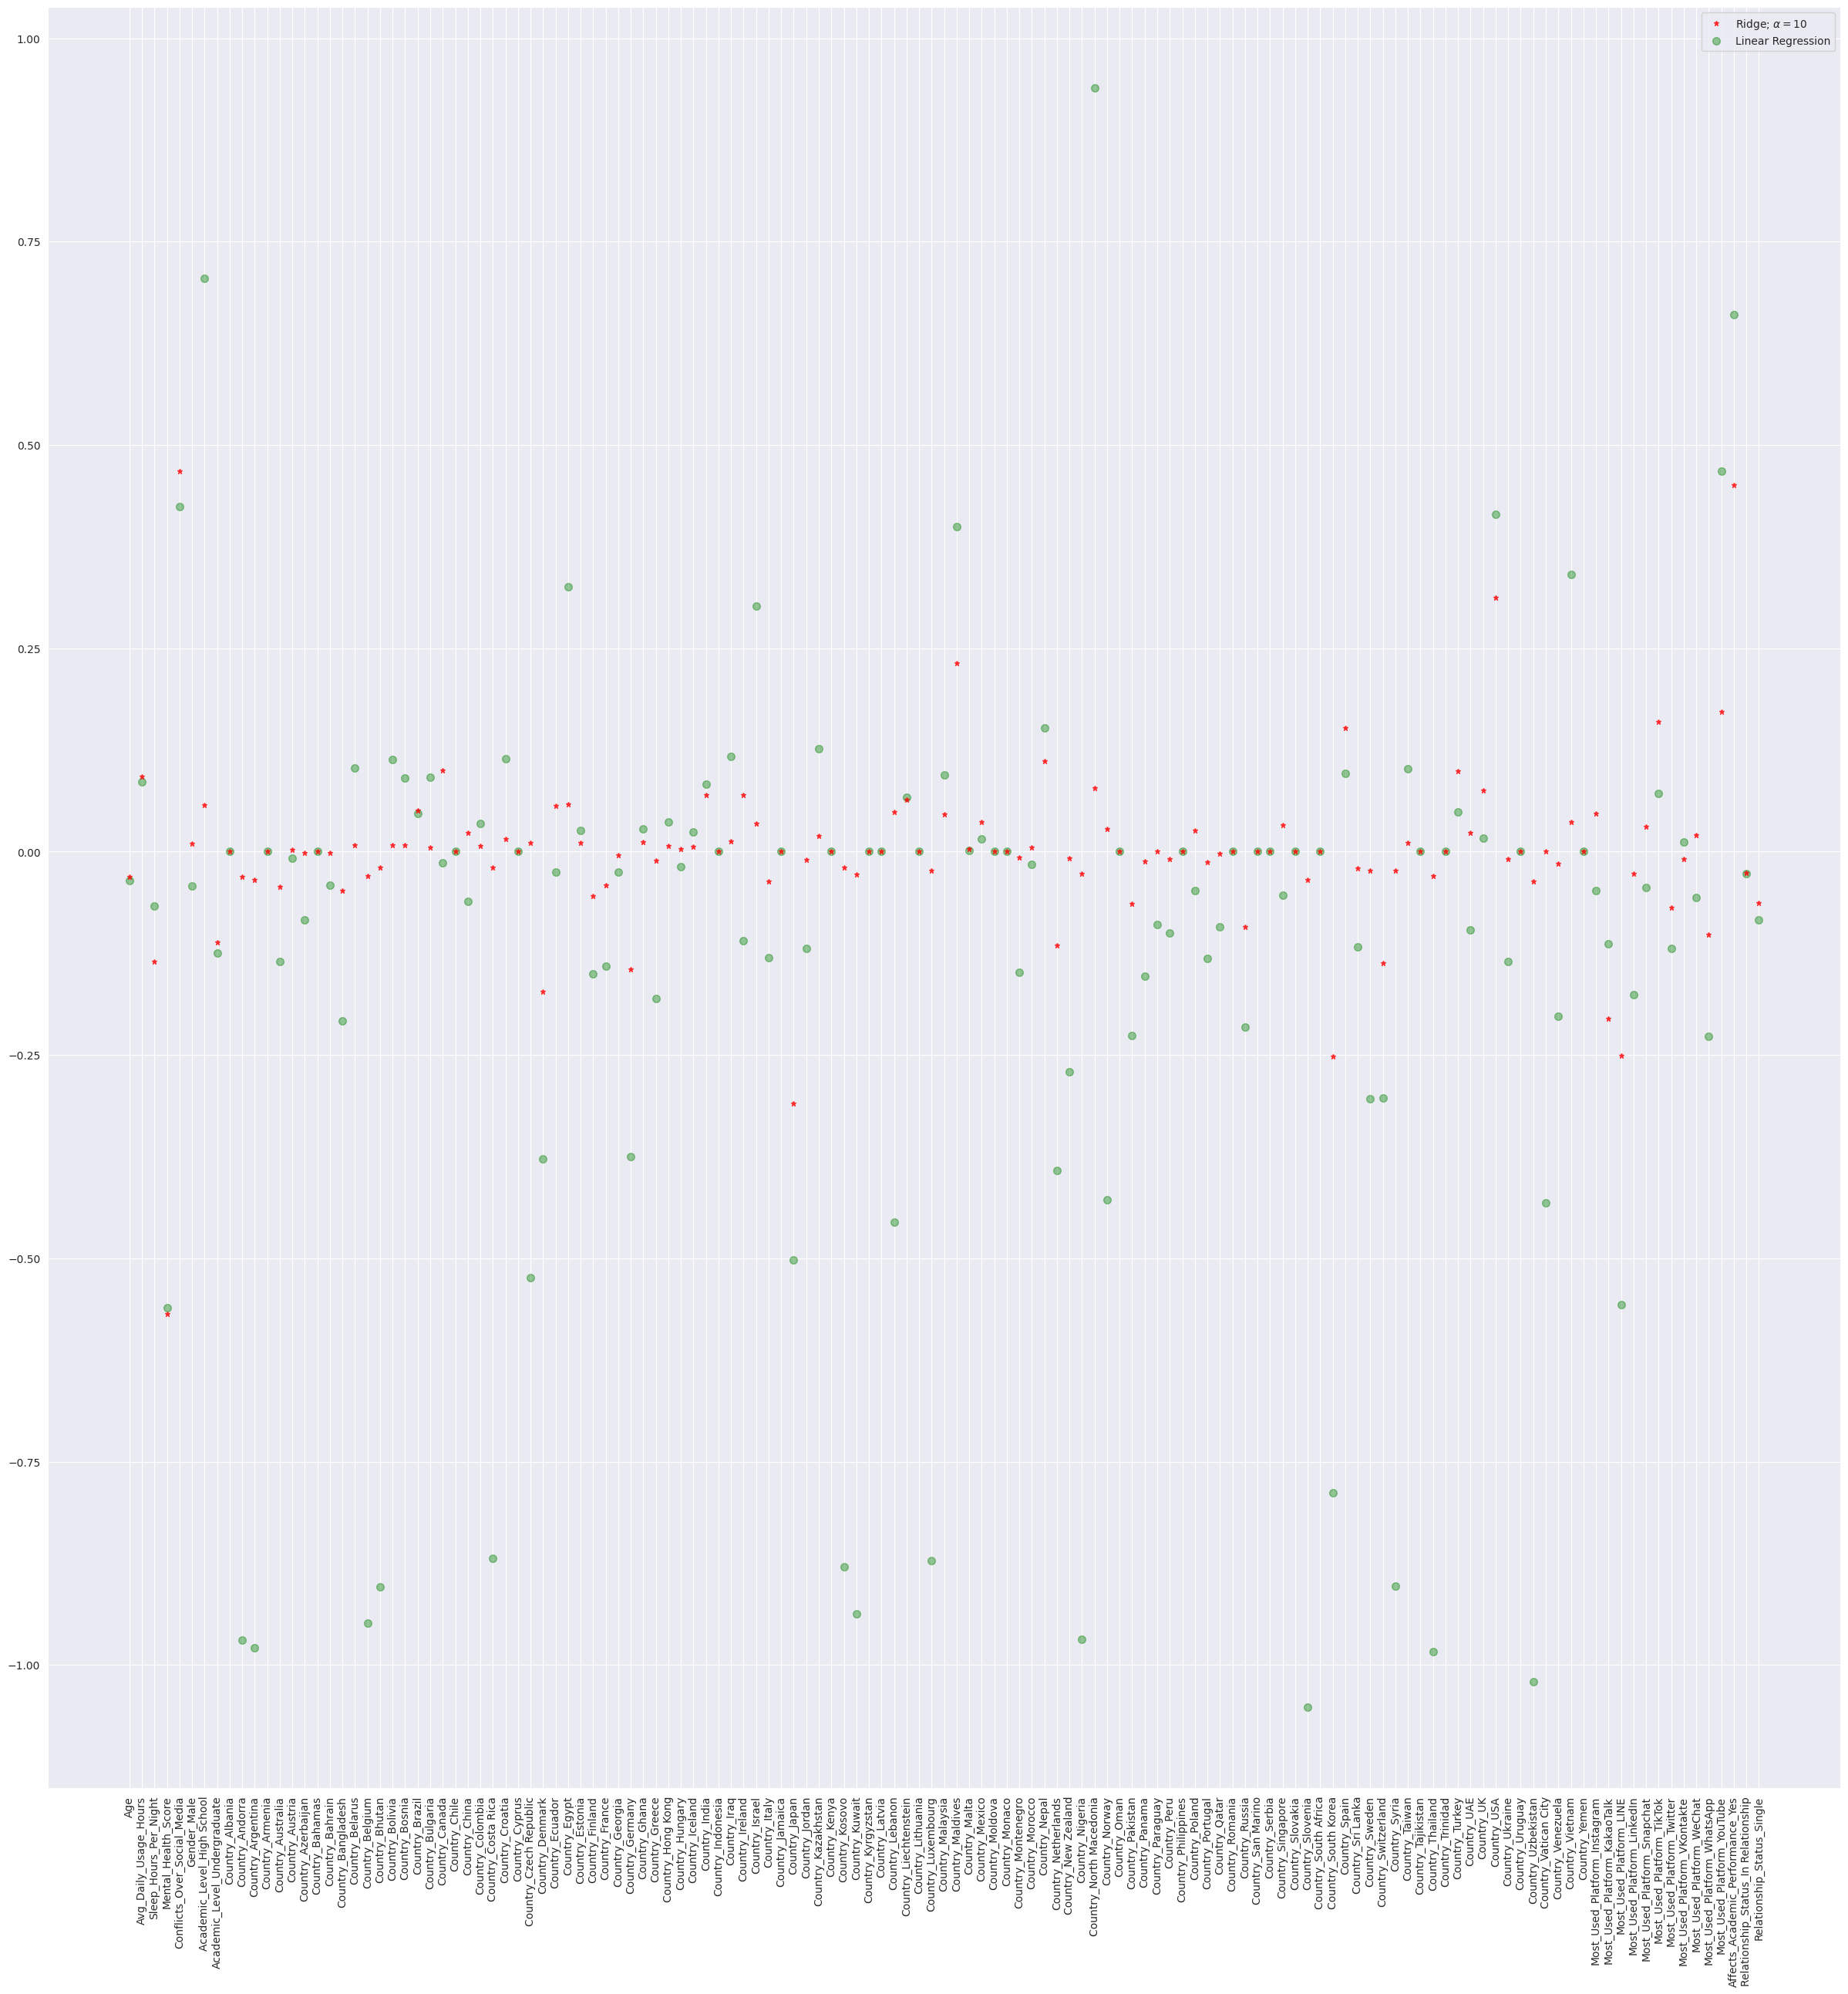

In [ ]:
features = df_encoded.drop('Addicted_Score', axis=1).columns.tolist()

plt.figure(figsize = (30, 30))
plt.plot(features,ridgeReg.coef_,alpha=0.7,linestyle='none',marker='*',markersize=5,color='red',label=r'Ridge; $\alpha = 10$',zorder=7)
#plt.plot(rr100.coef_,alpha=0.5,linestyle='none',marker='d',markersize=6,color='blue',label=r'Ridge; $\alpha = 100$')
plt.plot(features,lr.coef_,alpha=0.4,linestyle='none',marker='o',markersize=7,color='green',label='Linear Regression')
plt.xticks(rotation = 90)
plt.legend()
plt.show()

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

display(df_encoded.head())

,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Gender_Male,Academic_Level_High School,Academic_Level_Undergraduate,Country_Albania,...,Most_Used_Platform_Snapchat,Most_Used_Platform_TikTok,Most_Used_Platform_Twitter,Most_Used_Platform_VKontakte,Most_Used_Platform_WeChat,Most_Used_Platform_WhatsApp,Most_Used_Platform_YouTube,Affects_Academic_Performance_Yes,Relationship_Status_In Relationship,Relationship_Status_Single
1,22,2.1,7.5,8,0,3,True,False,False,False,...,False,False,True,False,False,False,False,False,False,True
2,20,6.0,5.0,5,4,9,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
3,18,3.0,7.0,7,1,4,True,True,False,False,...,False,False,False,False,False,False,True,False,False,True
4,21,4.5,6.0,6,2,7,True,False,False,False,...,False,False,False,False,False,False,False,True,True,False
5,19,7.2,4.5,4,5,9,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
from sklearn.linear_model import LinearRegression, Ridge

# Train Linear Regression model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Train Ridge Regression model
ridgeReg = Ridge(alpha=10) # Using alpha=10 as indicated in the original plot code
ridgeReg.fit(X_train, y_train)

print("Linear Regression model trained.")
print("Ridge Regression model trained.")

Linear Regression model trained.
Ridge Regression model trained.


In [ ]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
X = df_encoded.drop('Addicted_Score', axis=1)
y = df_encoded['Addicted_Score']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (563, 131)
Shape of X_test: (141, 131)
Shape of y_train: (563,)
Shape of y_test: (141,)
